In [14]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier


seed = 1234
np.random.seed(seed)  


In [31]:
# read data
data = pd.read_csv('diabetes+130-us+hospitals+for+years+1999-2008/diabetic_data.csv')
# save original dataset
original_data = data.copy()

features_to_drop = ['weight', 'payer_code', 'medical_specialty']
data = data.drop(features_to_drop, axis=1)
# data['medical_specialty'] = data['medical_specialty'].replace('?', 'Missing')
data = data.replace('?', np.nan)

#dropping rows with missing race for now
data = data.dropna(subset='race')
data['diag_1'] = pd.to_numeric(data['diag_1'], errors='coerce')

data['diag_1'] = data['diag_1'].fillna('Missing')

data['diag_2'] = pd.to_numeric(data['diag_2'], errors='coerce')

data['diag_2'] = data['diag_2'].fillna('Missing')

data['diag_3'] = pd.to_numeric(data['diag_3'], errors='coerce')

data['diag_3'] = data['diag_3'].fillna('Missing')
data.drop_duplicates(['patient_nbr'], keep = 'first', inplace = True)
data = data.drop(['patient_nbr', 'encounter_id'], axis=1) 
print(len(data))

intervalDict = {'[0-10)' : 5,
'[10-20)' : 15,
'[20-30)' : 25, 
'[30-40)' : 35, 
'[40-50)' : 45, 
'[50-60)' : 55,
'[60-70)' : 65, 
'[70-80)' : 75,
'[80-90)' : 85,
'[90-100)' : 95}

data['age'] = data['age'].apply(lambda x : intervalDict[x])

# 1 = Emergency/Urgent, 5 = Not Available/NULL/Not Mapped, 3 = Elective, 4 = Newborn, 7 = Trauma Center
data['admission_type_id'] = data['admission_type_id'].apply(lambda x : 1 if int(x) in [1, 2] 
                                                            else (5 if int(x) in [5, 6, 8] 
                                                                  else int(x) ))
# 1 = Referral, 2 = Transfer, 3 = Nan, 4 = Delivery, etc. 
data['admission_source_id'] = data['admission_source_id'].apply(lambda x : 1 if int(x) in [2, 3] 
                                                                else (2 if int(x) in [4, 5, 6, 10, 22, 25] 
                                                                      else (3 if int(x) in [9, 15, 17, 20, 21] 
                                                                            else (4 if int(x) in [11, 13, 14] 
                                                                                  else int(x)))))

# discharge disposition categorization
data['discharge_disposition_id'] = data['discharge_disposition_id'].apply(
    lambda x: 1 if int(x) in [6, 8, 9, 13]
    else (2 if int(x) in [3, 4, 5, 14, 22, 23, 24]  # discharged to facility
    else (10 if int(x) in [12, 15, 16, 17]          # hospice
    else (11 if int(x) in [19, 20, 21]              # expired
    else (18 if int(x) in [25, 26]                  # psychiatric
      else int(x)))))
)

# remove patients that died or hospice related
data = data[~data.discharge_disposition_id.isin([11,13,14,19,20,21])]



# diagnostic categorization
def categorize_diagnosis(diag):

    if diag == 'Missing':
        return 'Missing'

    try:
        diag = float(diag)
    except:
        return 'Other'

    if 390 <= diag <= 459 or diag == 785:
        return 'Circulatory'
    elif 460 <= diag <= 519 or diag == 786:
        return 'Respiratory'
    elif 520 <= diag <= 579 or diag == 787:
        return 'Digestive'
    elif 250 <= diag < 251:
        return 'Diabetes'
    elif 800 <= diag <= 999:
        return 'Injury'
    elif 710 <= diag <= 739:
        return 'Musculoskeletal'
    elif 580 <= diag <= 629 or diag == 788:
        return 'Genitourinary'
    elif 140 <= diag <= 239:
        return 'Neoplasms'
    else:
        return 'Other'
    
data['diag_1_cat'] = data['diag_1'].apply(categorize_diagnosis)
data['diag_2_cat'] = data['diag_2'].apply(categorize_diagnosis)
data['diag_3_cat'] = data['diag_3'].apply(categorize_diagnosis)
data = data.drop(['diag_1', 'diag_2', 'diag_3'], axis=1) # dropping the original columns bc new ones were created

# response variable
data['readmitted'] = data['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
data['change'] = data['change'].apply(lambda x : 1 if x == 'Ch'
                                                 else 0)


data['diabetesMed'] = data['diabetesMed'].apply(lambda x : 0 if x == 'No'
                                                else 1)

for col in ["metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride", "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide", "examide", "citoglipton", "insulin", "glyburide-metformin", "glipizide-metformin", "glimepiride-pioglitazone", "metformin-rosiglitazone", "metformin-pioglitazone"]:
    data[col] = data[col].apply(lambda x : 1 if x == 'Up' 
            else ( -1 if x == 'Down'                                                          
            else ( 0 if x == 'Steady'
            else  -2)))


data['max_glu_serum'] = data['max_glu_serum'].apply(lambda x : 200 if x == '>200' 
                                                            else ( 300 if x == '>300'                                                          
                                                            else ( 100 if x == 'Norm'
                                                            else  0)))

data['A1Cresult'] = data['A1Cresult'].apply(lambda x : 7 if x == '>7' 
                                                         else (8 if  x == '>8'                                                        
                                                         else ( 5 if x == 'Norm'
                                                         else  0)))

data = pd.get_dummies(data, columns=['admission_type_id','admission_source_id', 'gender', 'race', 'diag_1_cat', 'diag_2_cat', 'diag_3_cat'])

data.head()
# print(len(data))

69668


,age,discharge_disposition_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,...,diag_3_cat_Circulatory,diag_3_cat_Diabetes,diag_3_cat_Digestive,diag_3_cat_Genitourinary,diag_3_cat_Injury,diag_3_cat_Missing,diag_3_cat_Musculoskeletal,diag_3_cat_Neoplasms,diag_3_cat_Other,diag_3_cat_Respiratory
0,5,18,1,41,0,1,0,0,0,1,...,False,False,False,False,False,True,False,False,False,False
1,15,1,3,59,0,18,0,0,0,9,...,False,False,False,False,False,False,False,False,True,False
2,25,1,2,11,5,13,2,0,1,6,...,False,False,False,False,False,True,False,False,False,False
3,35,1,2,44,1,16,0,0,0,7,...,True,False,False,False,False,False,False,False,False,False
4,45,1,1,51,0,8,0,0,0,5,...,False,True,False,False,False,False,False,False,False,False


In [47]:
# split test/train

# separate features and target
X = data.drop("readmitted", axis=1)
feature_names = X.columns

y = data["readmitted"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X.shape)
print(X.columns)
# verify the shape
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(68609, 86)
Index(['age', 'discharge_disposition_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient',
       'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed',
       'admission_type_id_1', 'admission_type_id_3', 'admission_type_id_4',
       'admission_type_id_5', 'admission_type_id_7', 'admission_source_id_1',
       'admission_source_id_2', 'admission_source_id_3',
       'admission_source_id_4', 'admission_source_id_7',
       '

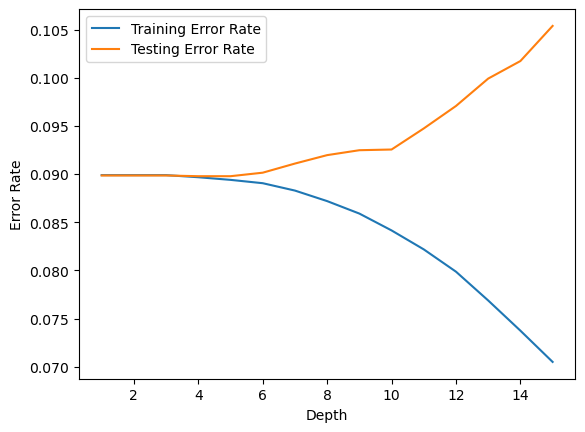

In [48]:
train_array = []
test_array = []

for i in range(1, 16):
    classifier = DecisionTreeClassifier(max_depth=i)
    classifier.fit(X_train, y_train)
    y_te_predict = classifier.predict(X_test)
    y_tr_predict = classifier.predict(X_train)
    test_accuracy = accuracy_score(y_test, y_te_predict)
    train_accuracy = accuracy_score(y_train, y_tr_predict)
    train_array.append(1 - train_accuracy)
    test_array.append(1 - test_accuracy)

plt.plot(list(range(1, 16)), train_array, label="Training Error Rate")
plt.plot(list(range(1, 16)), test_array, label="Testing Error Rate")
plt.xlabel("Depth")
plt.ylabel("Error Rate")
plt.legend()

In [49]:
classifier = DecisionTreeClassifier(max_depth=50)
classifier.fit(X_train, y_train)
y_te_predict = classifier.predict(X_test)
y_tr_predict = classifier.predict(X_train)
test_accuracy = accuracy_score(y_test, y_te_predict)
train_accuracy = accuracy_score(y_train, y_tr_predict)
print(f"test accuracy {test_accuracy}, train accuracy {train_accuracy}")
# plot_tree(classifier)

test accuracy 0.8248068794636351, train accuracy 0.9999817807495399


Text(0.5, 1.0, 'Feature Importance in Random Forest Classifier')

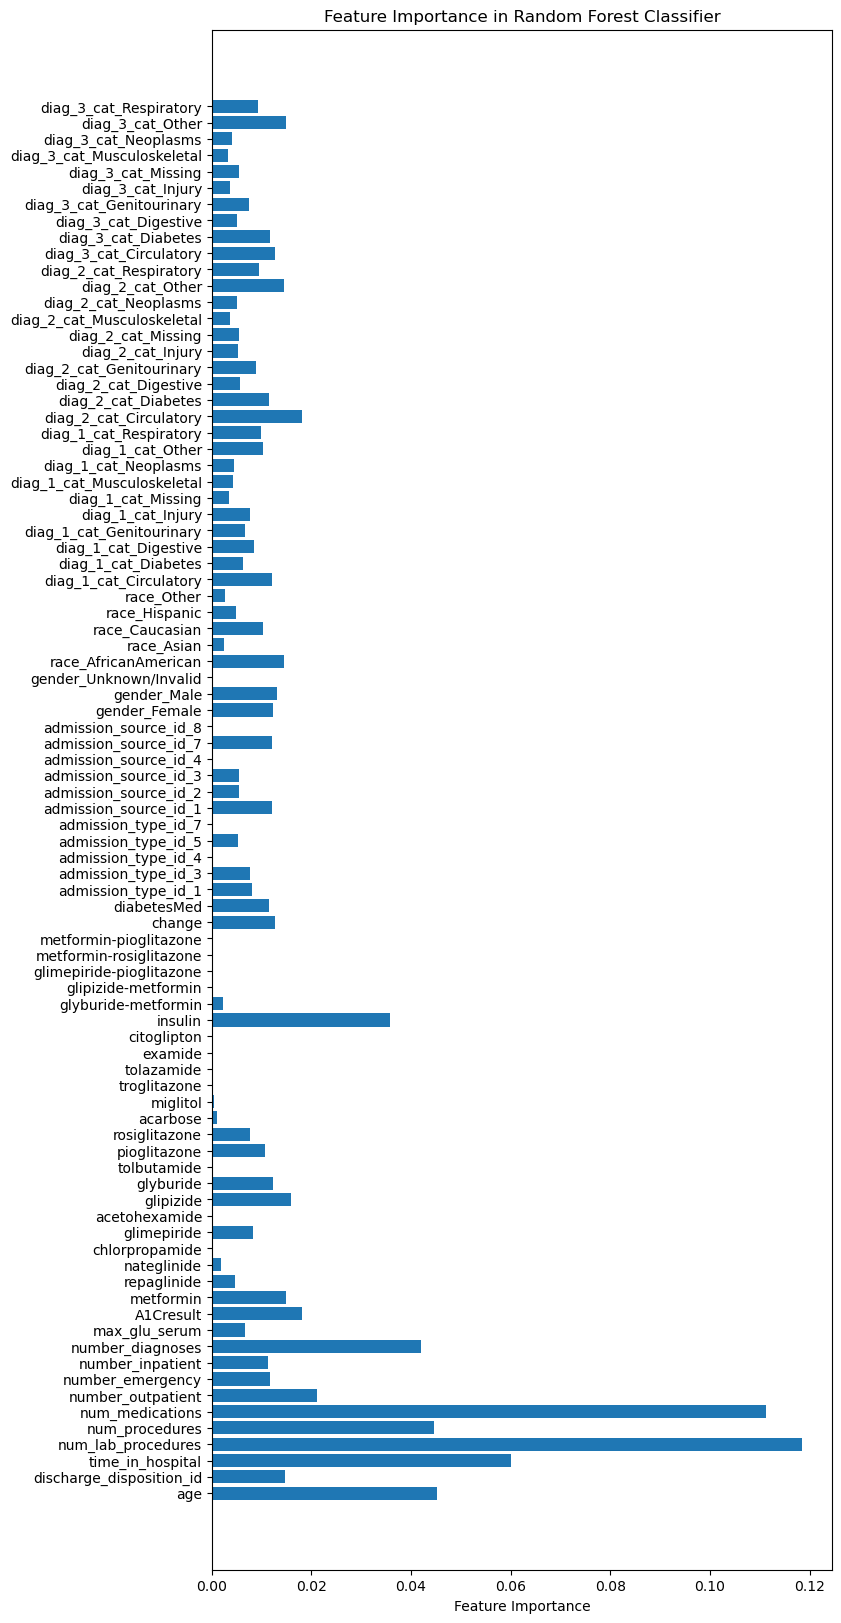

In [50]:
feature_importances = classifier.feature_importances_
plt.figure(figsize=(8, 20))
plt.barh(feature_names, feature_importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Decision Tree Classifier')

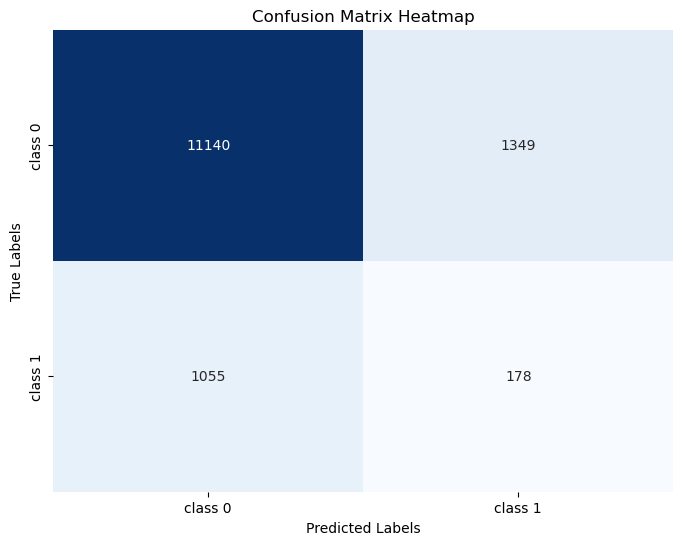

In [51]:
conf_matrix = confusion_matrix(y_test, y_te_predict)
target_names = ['class 0', 'class 1']
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False, 
            xticklabels=target_names, yticklabels=target_names)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Accuracy: 91.01%


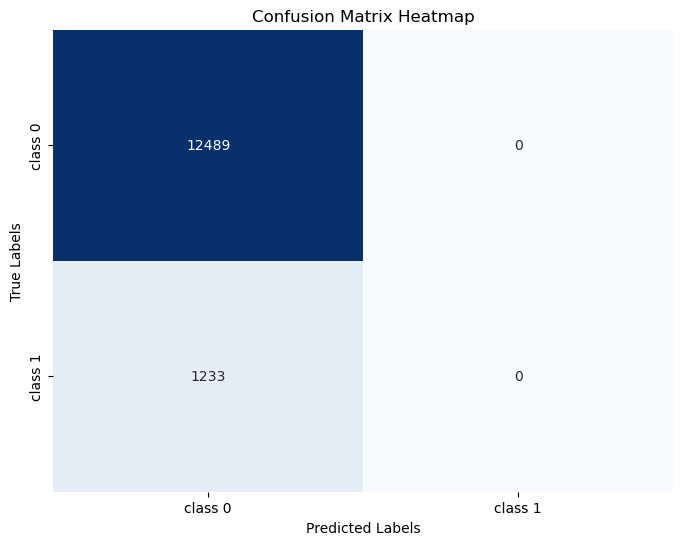

In [53]:
classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=60, )
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

conf_matrix = confusion_matrix(y_test, y_pred)
target_names = ['class 0', 'class 1']
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False, 
            xticklabels=target_names, yticklabels=target_names)

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


Text(0.5, 1.0, 'Feature Importance in Random Forest Classifier')

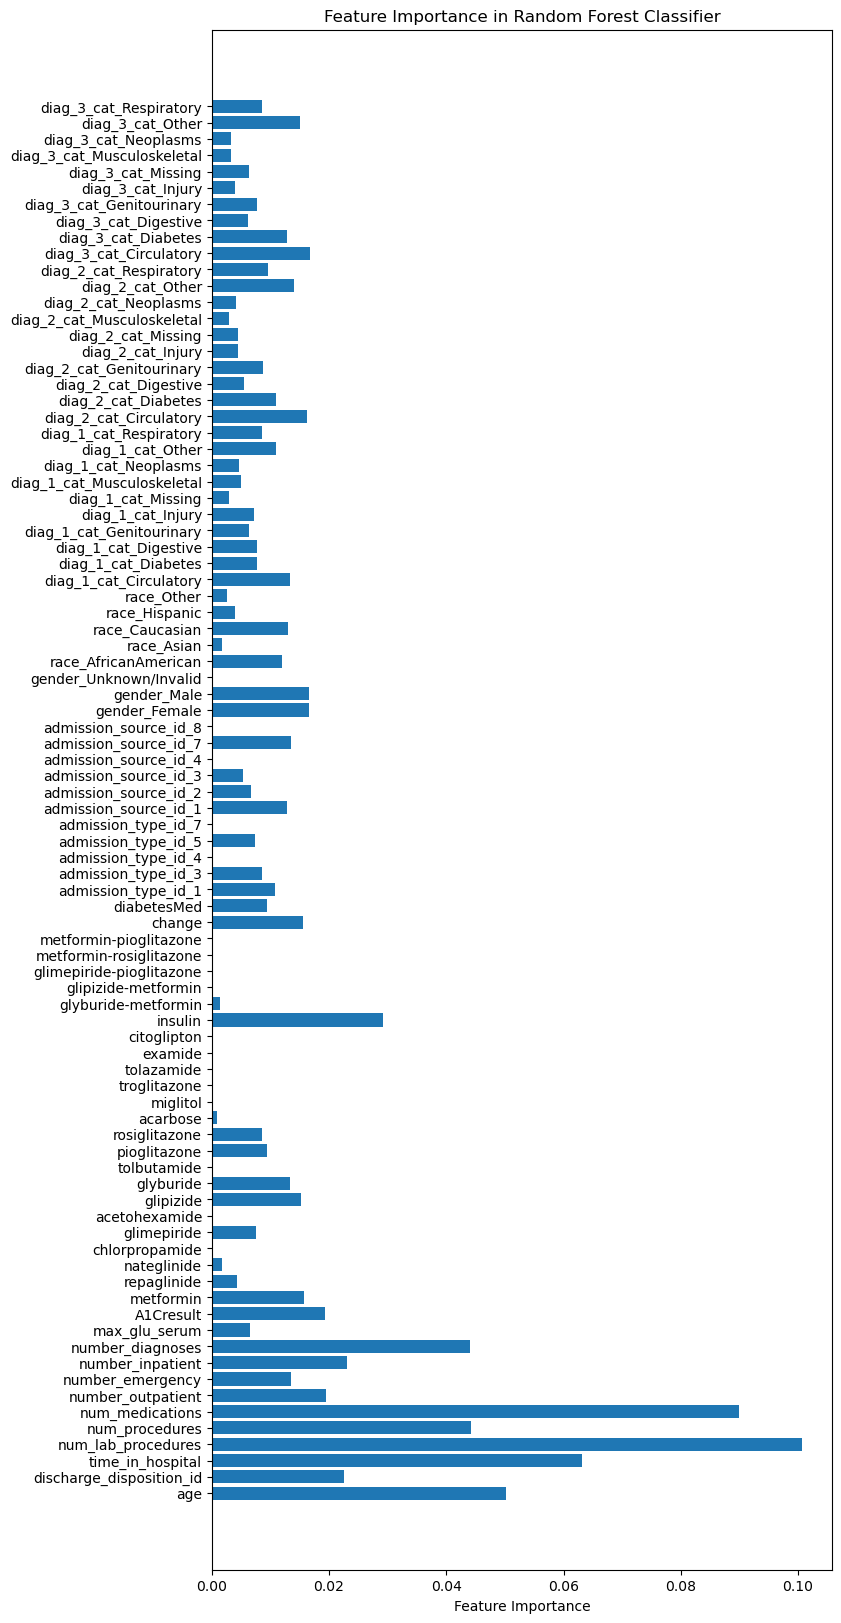

In [37]:
feature_importances = classifier.feature_importances_
plt.figure(figsize=(8, 20))
plt.barh(feature_names, feature_importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Random Forest Classifier')
# plt.show()